# 01 — Exploración: Contratos Electrónicos (FUENTE MADRE)

**Dataset**: SECOP II - Contratos Electrónicos (`jbjy-vk9h`)  
**Granularidad**: 1 fila = 1 contrato firmado electrónicamente  
**Filtro**: `tipo_de_contrato = 'Obra'`  
**Metodología**: CRISP-DM — Fase 2: Comprensión de los datos

---

## 1. Descripción general de la fuente

Contiene información detallada sobre contratos estatales firmados electrónicamente en Colombia:
- Identificación de la entidad contratante
- Información del contrato (ID, estado, tipo, modalidad, fechas, duración)
- Datos del proveedor adjudicado
- Información financiera (valores contratados, pagos, amortizaciones, saldos)
- Información presupuestal (BPIN, CDP, vigencia, origen de recursos)
- Indicadores de cumplimiento (ambiental, postconsumo, postconflicto, prórrogas)

**Rol en el modelo**: Es la **tabla base / fuente madre** porque:
1. El contrato firmado es la unidad de análisis
2. Contiene variables target directas (`dias_adicionados`, `estado_contrato`, `liquidación`)
3. Tiene FK a procesos y proveedores para enriquecer con features

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sodapy import Socrata
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

# Cargar config
with open("../dataset.json", "r", encoding="utf-8") as f:
    config = json.load(f)

APP_TOKEN = config["app_token"]
DATASET_ID = "jbjy-vk9h"  # contratosElectronicos
FUENTE = config["fuentes"]["contratosElectronicos"]

# Columnas definidas
cols_def = {c["nombreCampoApi"]: c for c in FUENTE["columnas"]}
print(f"Columnas definidas: {len(cols_def)}")
print(f"Dataset ID: {DATASET_ID}")

Columnas definidas: 87
Dataset ID: jbjy-vk9h


### 1.1 Conexión y conteos iniciales

In [2]:
client = Socrata("www.datos.gov.co", APP_TOKEN)

# Conteos
total = int(client.get(DATASET_ID, select="count(*)")[0]["count"])
obra = int(client.get(DATASET_ID, select="count(*)", where="tipo_de_contrato='Obra'")[0]["count"])

print(f"Total contratos electrónicos: {total:,}")
print(f"Contratos de Obra:            {obra:,}")
print(f"Proporción Obra:              {obra/total*100:.2f}%")

Total contratos electrónicos: 5,738,449
Contratos de Obra:            51,353
Proporción Obra:              0.89%


### 1.2 Descarga de muestra representativa

Descargamos los contratos de Obra. Con ~51K registros, podemos descargar todo en lotes.

In [3]:
# Descargar TODOS los contratos de Obra en lotes de 10,000
BATCH_SIZE = 10_000
all_records = []
offset = 0

while True:
    batch = client.get(
        DATASET_ID,
        where="tipo_de_contrato='Obra'",
        limit=BATCH_SIZE,
        offset=offset,
        order="id_contrato",
    )
    if not batch:
        break
    all_records.extend(batch)
    offset += BATCH_SIZE
    print(f"  Descargados: {len(all_records):,} registros...")

df = pd.DataFrame.from_records(all_records)
print(f"\nTotal descargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

  Descargados: 10,000 registros...


  Descargados: 20,000 registros...


  Descargados: 30,000 registros...


  Descargados: 40,000 registros...


  Descargados: 50,000 registros...


  Descargados: 51,353 registros...



Total descargado: 51,353 filas × 87 columnas


In [4]:
# Limpiar columnas que vienen como dict (ej: urlproceso = {"url": "..."})
for col in df.columns:
    if df[col].apply(type).eq(dict).any():
        print(f"  Columna '{col}' contiene dicts → convirtiendo a string")
        df[col] = df[col].apply(lambda x: x.get("url", str(x)) if isinstance(x, dict) else x)

# Guardar copia local para no re-descargar
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)
df.to_parquet(DATA_DIR / "contratos_electronicos_obra.parquet", index=False)
print(f"Guardado en {DATA_DIR / 'contratos_electronicos_obra.parquet'}")

  Columna 'urlproceso' contiene dicts → convirtiendo a string


Guardado en ..\data\contratos_electronicos_obra.parquet


## 2. Diccionario técnico resumido

Comparamos las columnas definidas en `dataset.json` contra los datos reales.

In [5]:
# Columnas reales vs definidas
cols_reales = set(df.columns)
cols_definidas = set(cols_def.keys())

# Excluir columnas internas de Socrata
cols_socrata = {c for c in cols_reales if c.startswith(":")}
cols_reales_limpias = cols_reales - cols_socrata

en_datos_no_def = cols_reales_limpias - cols_definidas
en_def_no_datos = cols_definidas - cols_reales_limpias

print(f"Columnas reales (sin Socrata): {len(cols_reales_limpias)}")
print(f"Columnas definidas:            {len(cols_definidas)}")
print(f"\nEn datos pero NO en definición: {len(en_datos_no_def)}")
for c in sorted(en_datos_no_def):
    print(f"  + {c}")
print(f"\nEn definición pero NO en datos: {len(en_def_no_datos)}")
for c in sorted(en_def_no_datos):
    print(f"  - {c}")

Columnas reales (sin Socrata): 87
Columnas definidas:            87

En datos pero NO en definición: 0

En definición pero NO en datos: 0


In [6]:
# Diccionario técnico: tipo real observado vs tipo esperado
dict_tecnico = []
for col in df.columns:
    if col.startswith(":"):
        continue
    
    info = cols_def.get(col, {})
    serie = df[col]
    
    # Calcular nulos (incluyendo "No Definido", "No definido", "No D", "No aplica")
    sentineles = ["No Definido", "No definido", "No D", "No aplica", "No Definido ", "Sin Descripcion"]
    n_null = serie.isna().sum()
    n_sentinel = serie.isin(sentineles).sum()
    n_total_missing = n_null + n_sentinel
    
    dict_tecnico.append({
        "campo_api": col,
        "nombre": info.get("nombreColumna", "(no definido)"),
        "tipo_esperado": info.get("tipo", "(no definido)"),
        "tipo_real": serie.dtype,
        "no_nulos": serie.notna().sum(),
        "nulos_reales": n_null,
        "sentineles": n_sentinel,
        "total_missing": n_total_missing,
        "pct_missing": round(n_total_missing / len(df) * 100, 1),
        "n_unicos": serie.nunique(),
        "ejemplo": serie.dropna().iloc[0] if serie.notna().any() else None,
    })

df_dict = pd.DataFrame(dict_tecnico)
print(f"Columnas analizadas: {len(df_dict)}")
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 40):
    display(df_dict.sort_values("pct_missing", ascending=False))

Columnas analizadas: 87


,campo_api,nombre,tipo_esperado,tipo_real,no_nulos,nulos_reales,sentineles,total_missing,pct_missing,n_unicos,ejemplo
50,pilares_del_acuerdo,Pilares del Acuerdo,Texto,str,51353,0,51219,51219,99.7,14,No aplica
49,puntos_del_acuerdo,Puntos del Acuerdo,Texto,str,51353,0,51219,51219,99.7,5,No aplica
82,tipo_de_documento_ordenador_de_pago,Tipo de documento Ordenador de Pago,Texto,str,51353,0,48736,48736,94.9,7,No definido
83,n_mero_de_documento_ordenador_de_pago,Número de documento Ordenador de Pago,Texto,str,51353,0,48736,48736,94.9,907,No definido
81,nombre_ordenador_de_pago,Nombre Ordenador de Pago,Texto,str,51353,0,48736,48736,94.9,908,No definido
86,fecha_de_notificaci_n_de_prorrogaci_n,Fecha de notificación de prorrogación,Marca de tiempo variable,str,6312,45041,0,45041,87.7,2029,2019-09-23T00:00:00.000
85,descripcion_documentos_tipo,Descripcion Documentos Tipo,Texto,str,51353,0,41154,41154,80.1,9,No definido
73,n_mero_de_cuenta,Número de cuenta,Texto,str,51353,0,39124,39124,76.2,5574,16878458173
71,nombre_del_banco,Nombre del banco,Texto,str,51353,0,38724,38724,75.4,288,BANCOLOMBIA
72,tipo_de_cuenta,Tipo de cuenta,Texto,str,51353,0,38667,38667,75.3,3,Corriente


## 3. Análisis de distribuciones clave

### 3.1 Estado del contrato

ESTADO DEL CONTRATO
estado_contrato
Modificado           16390
terminado            12003
En ejecución         10331
Cerrado               3222
Aprobado              2694
Borrador              2507
Cancelado             1781
Suspendido            1283
enviado Proveedor      661
En aprobación          441
cedido                  40
Name: count, dtype: int64

Total: 51,353


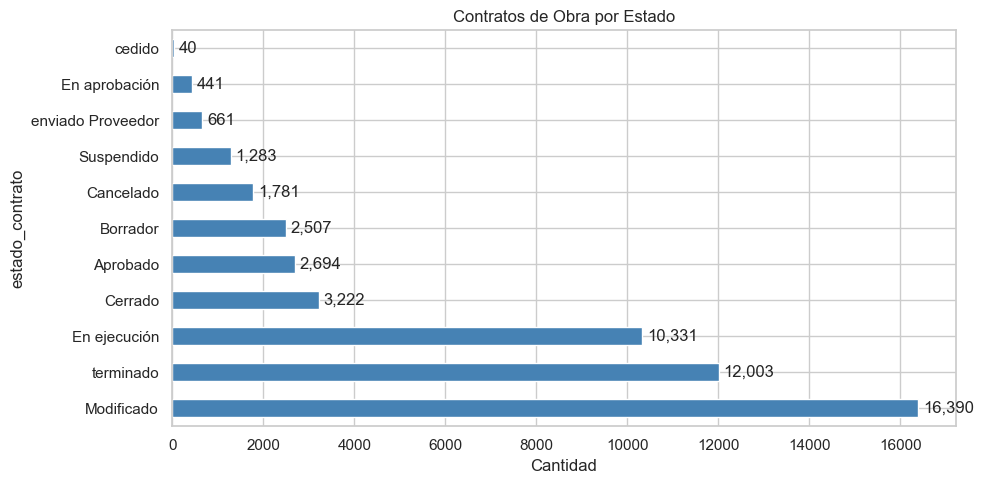

In [7]:
# Estado del contrato
print("ESTADO DEL CONTRATO")
estado_counts = df["estado_contrato"].value_counts()
print(estado_counts)
print(f"\nTotal: {estado_counts.sum():,}")

fig, ax = plt.subplots(figsize=(10, 5))
estado_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Contratos de Obra por Estado")
ax.set_xlabel("Cantidad")
for i, v in enumerate(estado_counts):
    ax.text(v + 100, i, f"{v:,}", va="center")
plt.tight_layout()
plt.show()

MODALIDAD DE CONTRATACIÓN
modalidad_de_contratacion
Selección Abreviada de Menor Cuantía                           14129
Mínima cuantía                                                 10442
Contratación directa                                           10239
Licitación pública Obra Publica                                 9154
Contratación régimen especial                                   2987
Contratación régimen especial (con ofertas)                     2006
Contratación Directa (con ofertas)                              1648
Licitación pública                                               437
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes      311
Name: count, dtype: int64


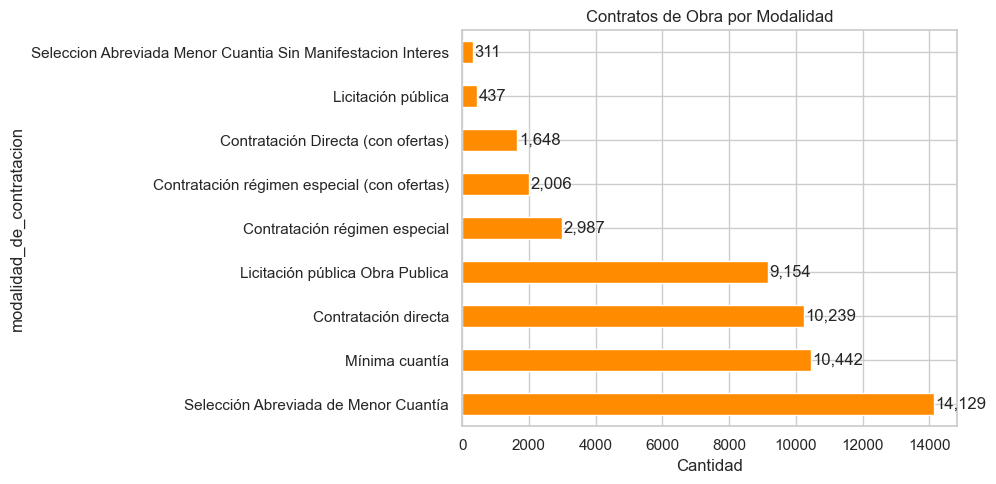

In [8]:
# Modalidad de contratación
print("MODALIDAD DE CONTRATACIÓN")
modal_counts = df["modalidad_de_contratacion"].value_counts()
print(modal_counts)

fig, ax = plt.subplots(figsize=(10, 5))
modal_counts.plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Contratos de Obra por Modalidad")
ax.set_xlabel("Cantidad")
for i, v in enumerate(modal_counts):
    ax.text(v + 50, i, f"{v:,}", va="center")
plt.tight_layout()
plt.show()

### Nota: ¿Por qué filtrar por `tipo_de_contrato` y no por `modalidad_de_contratacion`?

En SECOP II, **Modalidad** y **Tipo de contrato** son ejes independientes:

- **Modalidad de contratación** = CÓMO se selecciona al proveedor (mecanismo: licitación, contratación directa, mínima cuantía, etc.)
- **Tipo de contrato** = QUÉ tipo de contrato es (naturaleza jurídica: Obra, Prestación de servicios, Compraventa, etc.)

Si filtráramos solo por la modalidad "Licitación pública Obra Publica", capturaríamos únicamente el **17.8%** de los contratos de obra. El restante 82% entra por otras modalidades (selección abreviada, mínima cuantía, contratación directa, etc.).

Por eso el filtro correcto es `tipo_de_contrato = 'Obra'`, que captura **todos** los contratos de obra independientemente de su modalidad de selección. La modalidad queda como una **feature** del modelo, no como criterio de filtro.

### 3.2 Liquidación y prórrogas

In [9]:
# Liquidación
print("LIQUIDACIÓN")
print(df["liquidaci_n"].value_counts())

print("\nPUEDE SER PRORROGADO")
print(df["el_contrato_puede_ser_prorrogado"].value_counts())

print("\nREVERSIÓN")
print(df["reversion"].value_counts())

LIQUIDACIÓN
liquidaci_n
No    25873
Si    25480
Name: count, dtype: int64

PUEDE SER PRORROGADO
el_contrato_puede_ser_prorrogado
No    42125
Si     9228
Name: count, dtype: int64

REVERSIÓN
reversion
No    51325
Si       28
Name: count, dtype: int64


### 3.3 Variable TARGET: días adicionados

In [10]:
# Convertir dias_adicionados a numérico
df["dias_adicionados_num"] = pd.to_numeric(df["dias_adicionados"], errors="coerce")

print("DÍAS ADICIONADOS — Estadísticas")
print(df["dias_adicionados_num"].describe())

# Distribución binaria
tiene_extension = (df["dias_adicionados_num"] > 0).sum()
sin_extension = (df["dias_adicionados_num"] == 0).sum()
nulos = df["dias_adicionados_num"].isna().sum()

print(f"\nCon extensión (dias > 0): {tiene_extension:,} ({tiene_extension/len(df)*100:.1f}%)")
print(f"Sin extensión (dias = 0): {sin_extension:,} ({sin_extension/len(df)*100:.1f}%)")
print(f"Nulos:                    {nulos:,}")

# Balance de clases para el target binario
print(f"\nBalance target 'tiene_extension': {tiene_extension}:{sin_extension} = 1:{sin_extension/max(tiene_extension,1):.1f}")

DÍAS ADICIONADOS — Estadísticas
count    51353.000000
mean        17.189823
std         55.865452
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2934.000000
Name: dias_adicionados_num, dtype: float64

Con extensión (dias > 0): 11,530 (22.5%)
Sin extensión (dias = 0): 39,823 (77.5%)
Nulos:                    0

Balance target 'tiene_extension': 11530:39823 = 1:3.5


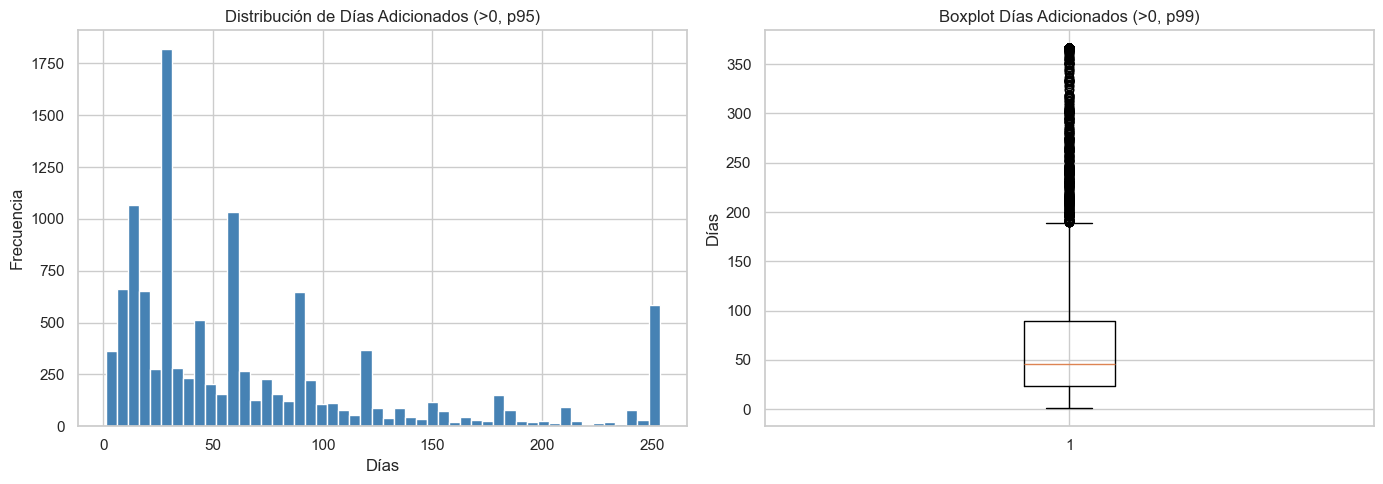


Percentiles de días adicionados (>0):
  p25: 24 días
  p50: 46 días
  p75: 90 días
  p90: 180 días
  p95: 254 días
  p99: 366 días


In [11]:
# Distribución de días adicionados (solo > 0)
dias_positivos = df.loc[df["dias_adicionados_num"] > 0, "dias_adicionados_num"]

if len(dias_positivos) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(dias_positivos.clip(upper=dias_positivos.quantile(0.95)), bins=50, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribución de Días Adicionados (>0, p95)")
    axes[0].set_xlabel("Días")
    axes[0].set_ylabel("Frecuencia")
    
    # Boxplot
    axes[1].boxplot(dias_positivos.clip(upper=dias_positivos.quantile(0.99)), vert=True)
    axes[1].set_title("Boxplot Días Adicionados (>0, p99)")
    axes[1].set_ylabel("Días")
    
    plt.tight_layout()
    plt.show()
    
    # Percentiles
    print("\nPercentiles de días adicionados (>0):")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"  p{p}: {dias_positivos.quantile(p/100):.0f} días")
else:
    print("No hay contratos con días adicionados > 0")

### 3.4 Variables financieras

In [12]:
# Convertir campos financieros a numérico
campos_financieros = [
    "valor_del_contrato", "valor_de_pago_adelantado", "valor_facturado",
    "valor_pendiente_de_pago", "valor_pagado", "valor_amortizado",
    "valor_pendiente_de", "valor_pendiente_de_ejecucion",
    "saldo_cdp", "saldo_vigencia",
    "presupuesto_general_de_la_nacion_pgn", "sistema_general_de_participaciones",
    "sistema_general_de_regal_as",
    "recursos_propios_alcald_as_gobernaciones_y_resguardos_ind_genas_",
    "recursos_de_credito", "recursos_propios",
]

for col in campos_financieros:
    if col in df.columns:
        df[col + "_num"] = pd.to_numeric(df[col], errors="coerce")

# Estadísticas del valor del contrato
print("VALOR DEL CONTRATO (COP)")
print(df["valor_del_contrato_num"].describe().apply(lambda x: f"{x:,.0f}"))

VALOR DEL CONTRATO (COP)
count               51,353
mean         3,023,231,314
std         43,781,859,648
min                      0
25%             54,911,756
50%            201,571,545
75%            869,752,000
max      7,127,629,832,600
Name: valor_del_contrato_num, dtype: str


In [13]:
# Detección de outliers en valor del contrato
valor = df["valor_del_contrato_num"].dropna()

print("ANÁLISIS DE OUTLIERS — Valor del Contrato")
print(f"  Negativos:     {(valor < 0).sum():,}")
print(f"  Cero:          {(valor == 0).sum():,}")
print(f"  > 1 billón:    {(valor > 1e12).sum():,}")
print(f"  > 100 mil M:   {(valor > 1e11).sum():,}")
print(f"  > 10 mil M:    {(valor > 1e10).sum():,}")

# Percentiles relevantes
print("\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:2d}: ${valor.quantile(p/100):>20,.0f} COP")

ANÁLISIS DE OUTLIERS — Valor del Contrato
  Negativos:     0
  Cero:          705
  > 1 billón:    5
  > 100 mil M:   182
  > 10 mil M:    2,358

Percentiles:
  p 1: $                   0 COP
  p 5: $          12,162,853 COP
  p10: $          23,729,055 COP
  p25: $          54,911,756 COP
  p50: $         201,571,545 COP
  p75: $         869,752,000 COP
  p90: $       3,703,857,375 COP
  p95: $       9,034,413,160 COP
  p99: $      42,786,128,560 COP


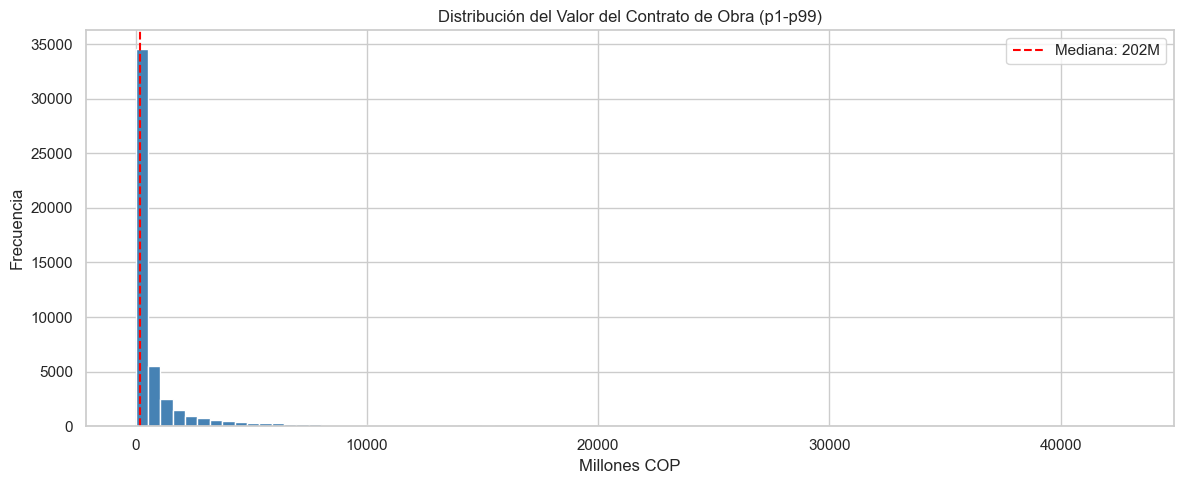

In [14]:
# Distribución del valor del contrato (rango intercuartil)
q01 = valor.quantile(0.01)
q99 = valor.quantile(0.99)
valor_filtrado = valor[(valor >= q01) & (valor <= q99)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(valor_filtrado / 1e6, bins=80, color="steelblue", edgecolor="white")
ax.set_title("Distribución del Valor del Contrato de Obra (p1-p99)")
ax.set_xlabel("Millones COP")
ax.set_ylabel("Frecuencia")
ax.axvline(valor.median() / 1e6, color="red", linestyle="--", label=f"Mediana: {valor.median()/1e6:,.0f}M")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Análisis de sobrecosto potencial: valor_pagado vs valor_del_contrato
df_financiero = df[["valor_del_contrato_num", "valor_pagado_num"]].dropna()
df_financiero = df_financiero[df_financiero["valor_del_contrato_num"] > 0]

# Calcular ratio de sobrecosto
df_financiero["sobrecosto_ratio"] = (
    (df_financiero["valor_pagado_num"] - df_financiero["valor_del_contrato_num"]) 
    / df_financiero["valor_del_contrato_num"]
)

print("RATIO DE SOBRECOSTO (valor_pagado - valor_contrato) / valor_contrato")
print(df_financiero["sobrecosto_ratio"].describe())

con_sobrecosto = (df_financiero["sobrecosto_ratio"] > 0.01).sum()  # > 1%
print(f"\nContratos con sobrecosto > 1%: {con_sobrecosto:,} ({con_sobrecosto/len(df_financiero)*100:.1f}%)")
print(f"Contratos con pago = 0:        {(df_financiero['valor_pagado_num'] == 0).sum():,}")

RATIO DE SOBRECOSTO (valor_pagado - valor_contrato) / valor_contrato
count    50648.000000
mean        -0.717842
std          0.432453
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -0.138912
max          0.662938
Name: sobrecosto_ratio, dtype: float64

Contratos con sobrecosto > 1%: 7 (0.0%)
Contratos con pago = 0:        34,629


### 3.5 Variables temporales

In [16]:
# Parsear fechas
fechas = ["fecha_de_firma", "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato", "ultima_actualizacion"]
for col in fechas:
    if col in df.columns:
        df[col + "_dt"] = pd.to_datetime(df[col], errors="coerce")

# Rango temporal
print("RANGOS TEMPORALES")
for col in fechas:
    dt_col = col + "_dt"
    if dt_col in df.columns:
        serie = df[dt_col].dropna()
        print(f"  {col}:")
        print(f"    Min: {serie.min()}")
        print(f"    Max: {serie.max()}")
        print(f"    Nulos: {df[dt_col].isna().sum():,}")

RANGOS TEMPORALES
  fecha_de_firma:
    Min: 2016-09-23 00:00:00
    Max: 2026-02-26 00:00:00
    Nulos: 5,378
  fecha_de_inicio_del_contrato:
    Min: 1899-11-24 00:00:00
    Max: 2026-03-02 00:00:00
    Nulos: 6,378
  fecha_de_fin_del_contrato:
    Min: 2015-12-15 00:00:00
    Max: 2047-07-31 00:00:00
    Nulos: 1,565
  ultima_actualizacion:
    Min: 2017-04-05 00:00:00
    Max: 2026-02-26 00:00:00
    Nulos: 18,052


In [17]:
# Duración del contrato — analizar formato texto
print("DURACIÓN DEL CONTRATO — Valores únicos (muestra)")
duracion = df["duraci_n_del_contrato"].value_counts()
print(f"Valores únicos: {duracion.shape[0]}")
print(f"\nTop 20:")
print(duracion.head(20))

# Detectar unidades de duración
print("\nPatrones de duración:")
sentineles_dur = df["duraci_n_del_contrato"].isin(["No definido", "No Definido"])
print(f"  'No definido': {sentineles_dur.sum():,}")
print(f"  Con valor:     {(~sentineles_dur).sum():,}")

DURACIÓN DEL CONTRATO — Valores únicos (muestra)
Valores únicos: 986

Top 20:
duraci_n_del_contrato
2 Mes(es)      3656
3 Mes(es)      3548
No definido    3196
Dia(s)         3179
4 Mes(es)      2333
1 Mes(es)      2165
30 Dia(s)      2043
10 Mes(es)     1780
5 Mes(es)      1662
45 Dia(s)      1569
6 Mes(es)      1471
60 Dia(s)      1415
8 Mes(es)      1338
15 Dia(s)      1132
90 Dia(s)       905
20 Dia(s)       856
7 Mes(es)       785
12 Mes(es)      708
75 Dia(s)       614
9 Mes(es)       506
Name: count, dtype: int64

Patrones de duración:
  'No definido': 3,196
  Con valor:     48,157


In [18]:
# Calcular duración en días desde fechas
if "fecha_de_inicio_del_contrato_dt" in df.columns and "fecha_de_fin_del_contrato_dt" in df.columns:
    df["duracion_dias_calc"] = (df["fecha_de_fin_del_contrato_dt"] - df["fecha_de_inicio_del_contrato_dt"]).dt.days
    
    dur = df["duracion_dias_calc"].dropna()
    print("DURACIÓN CALCULADA (fecha_fin - fecha_inicio) en días")
    print(dur.describe())
    
    print(f"\nNegativos: {(dur < 0).sum():,}")
    print(f"Cero:      {(dur == 0).sum():,}")
    print(f"> 5 años:  {(dur > 1825).sum():,}")

DURACIÓN CALCULADA (fecha_fin - fecha_inicio) en días
count    44975.000000
mean       205.226415
std        356.987761
min       -311.000000
25%         56.000000
50%        115.000000
75%        252.000000
max      46124.000000
Name: duracion_dias_calc, dtype: float64

Negativos: 23
Cero:      181
> 5 años:  114


### 3.6 Distribución geográfica

TOP 15 DEPARTAMENTOS — Contratos de Obra
departamento
Distrito Capital de Bogotá    15034
Antioquia                      5677
Valle del Cauca                2875
Cundinamarca                   2656
Boyacá                         2201
Caldas                         2064
Santander                      1884
No Definido                    1702
Tolima                         1393
Cauca                          1383
Bolívar                        1317
Norte de Santander             1286
Meta                           1239
Huila                          1222
Risaralda                       924
Name: count, dtype: int64


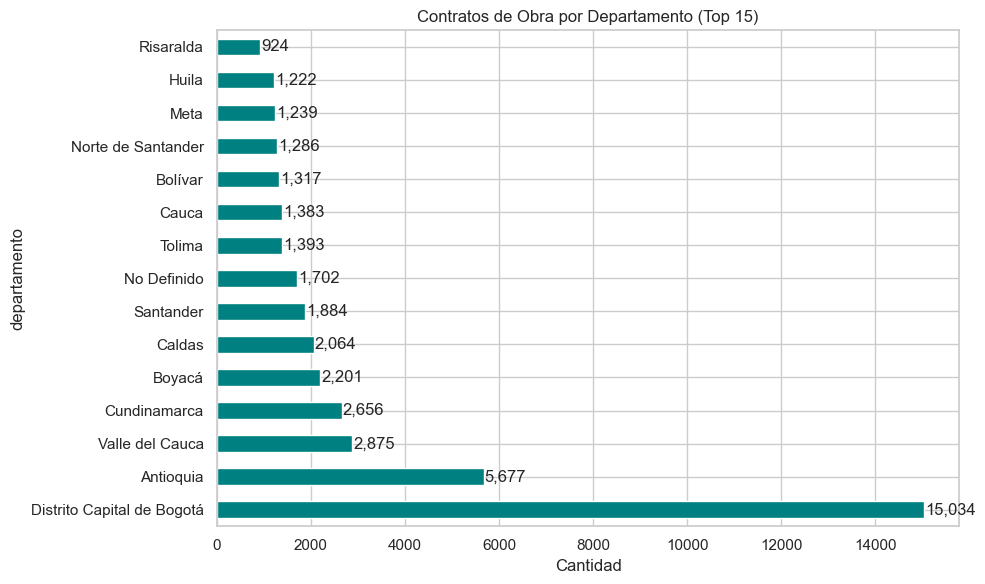

In [19]:
# Top departamentos
print("TOP 15 DEPARTAMENTOS — Contratos de Obra")
dept_counts = df["departamento"].value_counts().head(15)
print(dept_counts)

fig, ax = plt.subplots(figsize=(10, 6))
dept_counts.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Contratos de Obra por Departamento (Top 15)")
ax.set_xlabel("Cantidad")
for i, v in enumerate(dept_counts):
    ax.text(v + 20, i, f"{v:,}", va="center")
plt.tight_layout()
plt.show()

### 3.7 Variables del proveedor

In [20]:
# Es Pyme, Es Grupo
print("ES PYME")
print(df["es_pyme"].value_counts())

print("\nES GRUPO")
print(df["es_grupo"].value_counts())

# Proveedores más frecuentes
print("\nTOP 10 PROVEEDORES con más contratos de Obra")
top_prov = df["proveedor_adjudicado"].value_counts().head(10)
print(top_prov)

ES PYME
es_pyme
Si    29695
No    21658
Name: count, dtype: int64

ES GRUPO
es_grupo
No    40275
Si    11078
Name: count, dtype: int64

TOP 10 PROVEEDORES con más contratos de Obra
proveedor_adjudicado
Sin Descripcion                                       677
SAFRID INGENIERIA SAS                                 155
INNOVACION COLOMBIA SAS                               104
EMPRESA PARA EL DESARROLLO TERRITORIAL DE EL BAGRE    102
SIPCO SAS                                              90
OBRAS Y DISEÑOS DE INFRAESTRUCTURA SAS                 77
WRUSSY INGENIEROS S.A.S                                76
FGD                                                    74
ALCALDÍA DEL MUNICIPIO DE YACOPI                       69
CUMBRE INGENIERÍA SAS                                  66
Name: count, dtype: int64


## 4. Posibles llaves de integración

In [21]:
# Verificar unicidad de llaves
llaves = {
    "id_contrato": "PK → identifica cada contrato",
    "proceso_de_compra": "FK → procesosDeContratacion.id_del_proceso",
    "codigo_proveedor": "FK → proveedoresRegistrados.codigo",
    "referencia_del_contrato": "Referencia interna de la entidad",
    "codigo_entidad": "FK compartida con procesos y proveedores",
    "nit_entidad": "FK compartida",
}

for col, desc in llaves.items():
    if col in df.columns:
        unicos = df[col].nunique()
        nulos = df[col].isna().sum()
        es_unico = unicos == len(df)
        print(f"{col}:")
        print(f"  Valores únicos: {unicos:,} / {len(df):,} {'(ÚNICO)' if es_unico else '(NO único)'}")
        print(f"  Nulos: {nulos:,}")
        print(f"  Rol: {desc}")
        print(f"  Ejemplo: {df[col].dropna().iloc[0]}")
        print()

id_contrato:


  Valores únicos: 48,331 / 51,353 (NO único)
  Nulos: 0
  Rol: PK → identifica cada contrato
  Ejemplo: CO1.PCCNTR.1001032

proceso_de_compra:
  Valores únicos: 43,451 / 51,353 (NO único)
  Nulos: 0
  Rol: FK → procesosDeContratacion.id_del_proceso
  Ejemplo: CO1.BDOS.825935

codigo_proveedor:
  Valores únicos: 23,192 / 51,353 (NO único)
  Nulos: 0
  Rol: FK → proveedoresRegistrados.codigo
  Ejemplo: 701107773

referencia_del_contrato:
  Valores únicos: 45,910 / 51,353 (NO único)
  Nulos: 0
  Rol: Referencia interna de la entidad
  Ejemplo: 91-6-10029-19

codigo_entidad:
  Valores únicos: 2,534 / 51,353 (NO único)
  Nulos: 0
  Rol: FK compartida con procesos y proveedores
  Ejemplo: 701699357

nit_entidad:
  Valores únicos: 2,270 / 51,353 (NO único)
  Nulos: 0
  Rol: FK compartida
  Ejemplo: 900805219



In [22]:
# Formato de los IDs
print("FORMATOS DE ID")
for col in ["id_contrato", "proceso_de_compra"]:
    muestra = df[col].dropna().head(5).tolist()
    print(f"\n{col}:")
    for v in muestra:
        print(f"  {v}")

FORMATOS DE ID

id_contrato:
  CO1.PCCNTR.1001032
  CO1.PCCNTR.1001046
  CO1.PCCNTR.1001111
  CO1.PCCNTR.1001129
  CO1.PCCNTR.1001240

proceso_de_compra:
  CO1.BDOS.825935
  CO1.BDOS.813978
  CO1.BDOS.797027
  CO1.BDOS.853412
  CO1.BDOS.825838


## 5. Problemas de calidad detectados

In [23]:
# Resumen de calidad
print("="*80)
print("RESUMEN DE PROBLEMAS DE CALIDAD")
print("="*80)

# 1. Sentineles como "No Definido"
sentineles = ["No Definido", "No definido", "No D", "No aplica", "Sin Descripcion"]
print("\n1. SENTINELES 'No Definido' (campos con >50% sentineles):")
for col in df.columns:
    if col.startswith(":") or col.endswith("_num") or col.endswith("_dt") or col.endswith("_calc"):
        continue
    n_sent = df[col].isin(sentineles).sum()
    pct = n_sent / len(df) * 100
    if pct > 50:
        print(f"  {col}: {n_sent:,} ({pct:.1f}%)")

# 2. Nulos reales
print("\n2. NULOS REALES (campos con >10% nulos):")
for col in df.columns:
    if col.startswith(":") or col.endswith("_num") or col.endswith("_dt") or col.endswith("_calc"):
        continue
    n_null = df[col].isna().sum()
    pct = n_null / len(df) * 100
    if pct > 10:
        print(f"  {col}: {n_null:,} ({pct:.1f}%)")

# 3. Duplicados
n_dup = df["id_contrato"].duplicated().sum()
print(f"\n3. DUPLICADOS por id_contrato: {n_dup:,}")

# 4. Campos numéricos como texto
print("\n4. CAMPOS NUMÉRICOS COMO TEXTO (tipo esperado Número, pero dtype object):")
for col_info in FUENTE["columnas"]:
    campo = col_info["nombreCampoApi"]
    if col_info["tipo"] == "Número" and campo in df.columns:
        if df[campo].dtype == "object":
            print(f"  {campo} (definido como Número, recibido como texto)")

# 5. Leakage
print("\n5. RIESGO DE DATA LEAKAGE — Campos que son RESULTADO, no predictor:")
leakage_fields = [
    "valor_pagado", "valor_facturado", "valor_pendiente_de_pago",
    "valor_amortizado", "valor_pendiente_de", "valor_pendiente_de_ejecucion",
    "saldo_cdp", "saldo_vigencia", "fecha_inicio_liquidacion", "fecha_fin_liquidacion",
    "ultima_actualizacion", "fecha_de_notificaci_n_de_prorrogaci_n",
]
for f in leakage_fields:
    if f in df.columns:
        print(f"  ⚠ {f}")

RESUMEN DE PROBLEMAS DE CALIDAD

1. SENTINELES 'No Definido' (campos con >50% sentineles):
  c_digo_bpin: 30,091 (58.6%)
  anno_bpin: 30,091 (58.6%)
  puntos_del_acuerdo: 51,219 (99.7%)
  pilares_del_acuerdo: 51,219 (99.7%)
  domicilio_representante_legal: 33,183 (64.6%)
  tipo_de_identificaci_n_representante_legal: 31,489 (61.3%)
  identificaci_n_representante_legal: 31,260 (60.9%)
  nombre_del_banco: 38,724 (75.4%)
  tipo_de_cuenta: 38,667 (75.3%)
  n_mero_de_cuenta: 39,124 (76.2%)
  nombre_ordenador_de_pago: 48,736 (94.9%)
  tipo_de_documento_ordenador_de_pago: 48,736 (94.9%)
  n_mero_de_documento_ordenador_de_pago: 48,736 (94.9%)
  descripcion_documentos_tipo: 41,154 (80.1%)

2. NULOS REALES (campos con >10% nulos):
  fecha_de_firma: 5,378 (10.5%)
  fecha_de_inicio_del_contrato: 6,378 (12.4%)
  ultima_actualizacion: 18,052 (35.2%)
  fecha_inicio_liquidacion: 25,689 (50.0%)
  fecha_fin_liquidacion: 25,695 (50.0%)
  fecha_de_notificaci_n_de_prorrogaci_n: 45,041 (87.7%)

3. DUPLICADOS

## 6. Evaluación estratégica dentro de CRISP-DM

### Fase actual: Comprensión de datos (Data Understanding)

### Hallazgos clave:

1. **Volumen**: 51,353 contratos de Obra — suficiente para ML
2. **Target directo**: `dias_adicionados` existe y permite construir `tiene_extension` (binaria)
3. **Target derivado**: `sobrecosto_ratio` calculable desde `valor_pagado` vs `valor_del_contrato`
4. **Calidad**: Muchos campos con sentineles "No Definido" en lugar de NULL real. Campos numéricos llegan como texto.
5. **Leakage**: 12+ campos son resultado de la ejecución (valor_pagado, valor_facturado, etc.) — NO deben usarse como features
6. **Duración**: Viene como texto libre ("143 Dia(s)", "3 Mes(es)") — requiere parsing
7. **Llaves**: `id_contrato` es PK, `proceso_de_compra` conecta con procesos, `codigo_proveedor` con proveedores

### Qué sigue:
- Analizar `procesosDeContratacion` para obtener features pre-contrato
- Analizar `adiciones` para construir features de modificaciones (tipo, frecuencia)
- Analizar `proveedoresRegistrados` para perfil del proveedor

### Riesgos si avanzamos sin limpiar:
- Usar sentineles como categorías válidas distorsiona el modelo
- No parsear duración impide usar una feature clave
- Incluir campos de leakage inflaría artificialmente las métricas